# 01 - Explorare date

Notebook pentru săptămâna 12: încărcare dataset, inspectare, shape, canale și primele vizualizări.

## Step 1
 - check the path works
 - load the data
 - check file to be `strored dictionary object`


In [1]:
import numpy as np

path = "../data/raw/things-eeg2/raw-eeg/sub-01/ses-01/raw_eeg_training.npy"

data = np.load(path, allow_pickle=True)

print(type(data))
print(data.shape)

<class 'numpy.ndarray'>
()


## Step 2
- confirm that the needed keys exist

In [2]:
d = data.item()

print(d.keys())

dict_keys(['raw_eeg_data', 'ch_names', 'ch_types', 'sfreq', 'highpass', 'lowpass'])


## Step 3
- verify `raw.shape` (*number of chanels and number of samples*)
- sfreq count to be 1k (*sampling frequency exp: 1000Hz -> 1 sample every 1/1000 s*)
- the channel count (63 eeg + 1 stim)
- confirm the total channels

In [3]:
raw = d["raw_eeg_data"]
ch_names = d["ch_names"]
ch_types = d["ch_types"]
sfreq = d["sfreq"]

print("Raw shape:", raw.shape)
print("Sampling frequency:", sfreq)

print("Number of channel names:", len(ch_names))
print("Number of channel types:", len(ch_types))

print("First 5 channel names:", ch_names[:5])
print("Last channel:", ch_names[-1])

print("Last channel type:", ch_types[-1])

Raw shape: (64, 5450560)
Sampling frequency: 1000
Number of channel names: 64
Number of channel types: 64
First 5 channel names: ['Fp1', 'F3', 'F7', 'FT9', 'FC5']
Last channel: stim
Last channel type: stim


## Step 4
- validate the stim ch. contains usable event markers and their struct.
- check where they happend in time
- are they sparse (not noise const.)
- basically deriving grond truth, * was an image shown when the stim happened*

In [4]:
eeg = raw[:-1]
stim = raw[-1]

event_idx = np.where(stim != 0)[0]
event_values = stim[event_idx].astype(int)

print("Number of events:", len(event_idx))
print("First 10 event indices:", event_idx[:10])
print("First 10 event values:", event_values[:10])

Number of events: 16800
First 10 event indices: [11446 11646 11845 12045 12245 12445 12645 12845 13045 13245]
First 10 event values: [11742  8221  5879  3609 13717   741  7305 16160 11267  3344]


## Step 5
- verify events are not overlapping
- is stimulus time consistent
- is there clear separation between events
- cehck for invalid values
- check numeric min/max

In [5]:
event_diffs = np.diff(event_idx)

print("Min spacing (samples):", event_diffs.min())
print("Max spacing (samples):", event_diffs.max())
print("Mean spacing (samples):", event_diffs.mean())

print("NaNs in EEG:", np.isnan(eeg).sum())
print("Infs in EEG:", np.isinf(eeg).sum())

print("NaNs in stim:", np.isnan(stim).sum())
print("Infs in stim:", np.isinf(stim).sum())

print("EEG dtype:", eeg.dtype)
print("Stim dtype:", stim.dtype)

print("EEG min/max:", eeg.min(), eeg.max())
print("Stim min/max:", stim.min(), stim.max())

Min spacing (samples): 199
Max spacing (samples): 29705
Mean spacing (samples): 322.78558247514735
NaNs in EEG: 0
Infs in EEG: 0
NaNs in stim: 0
Infs in stim: 0
EEG dtype: float64
Stim dtype: float64
EEG min/max: -0.0026766595487390625 0.0009759562263843749
Stim min/max: 0.0 99999.0


## Step 6
- Plot the data : average time between stims
- visualise the stim channel over time (*0 on nothing, spike on stim*)
- red dots represent actual visual stim

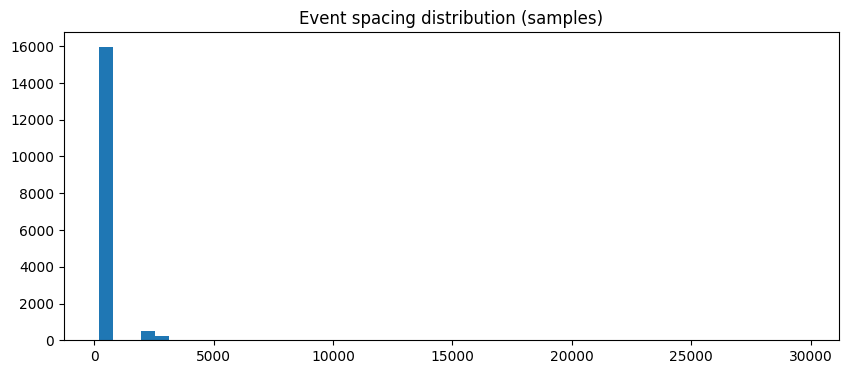

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.hist(event_diffs, bins=50)
plt.title("Event spacing distribution (samples)")
plt.show()

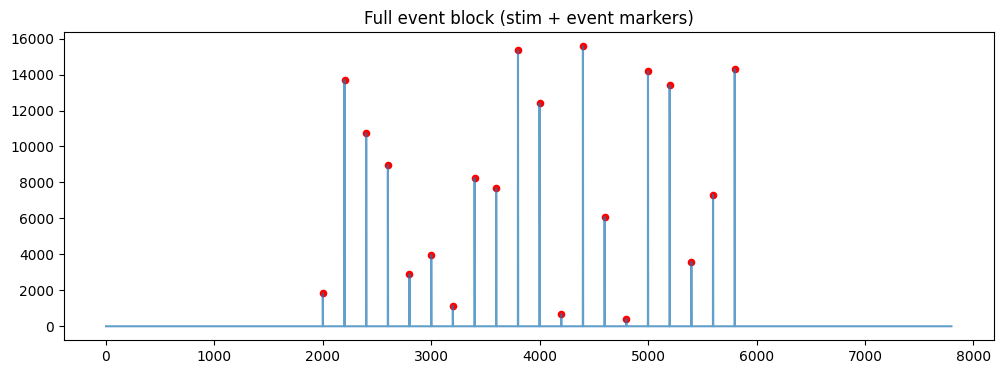

In [7]:
import matplotlib.pyplot as plt

start_event = 100
n_events = 20

block_events = event_idx[start_event:start_event + n_events]

plt.figure(figsize=(12,4))

plt.plot(stim[block_events[0] - 2000 : block_events[-1] + 2000], alpha=0.7)

plt.scatter(
    block_events - (block_events[0] - 2000),
    stim[block_events],
    color="red",
    s=20
)

plt.title("Full event block (stim + event markers)")
plt.show()

## Step 7
- plot representative EEG channels around one stimulus event
- verify temporal dynamics in raw EEG after event onset
- compare channel behavior in the same post-stimulus window

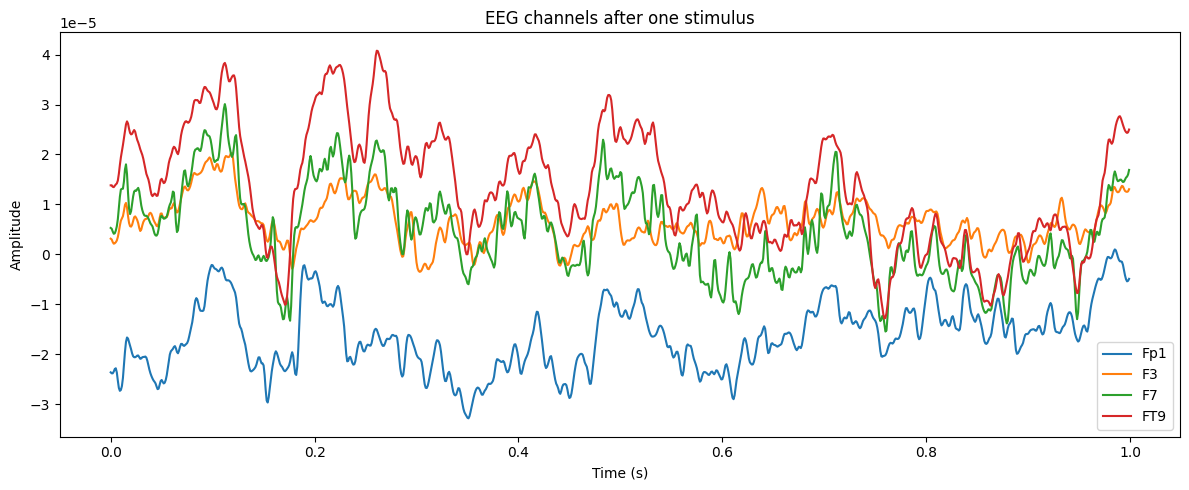

In [12]:
plt.figure(figsize=(12, 5))

start = event_idx[100]
window = 1000
end = min(start + window, eeg.shape[1])

t = np.arange(end - start) / sfreq  # secunde

for i in range(4):
    plt.plot(t, eeg[i, start:end], label=ch_names[i])

plt.title("EEG channels after one stimulus")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

## Step 8
- map the first valid EEG event to its corresponding image from the metadata
- display a small event-to-image table
- show the first image visually to make the EEG ↔ image link explicit

First 5 valid event ids: [11742  8221  5879  3609 13717]

Event -> image mapping:
event_id=11742 | concept=01175_roller_coaster | image_file=roller_coaster_02s.jpg
event_id= 8221 | concept=00823_lingerie | image_file=lingerie_01b.jpg
event_id= 5879 | concept=00588_gel | image_file=gel_09s.jpg
event_id= 3609 | concept=00361_corkscrew | image_file=corkscrew_09s.jpg
event_id=13717 | concept=01372_statue | image_file=statue_07s.jpg


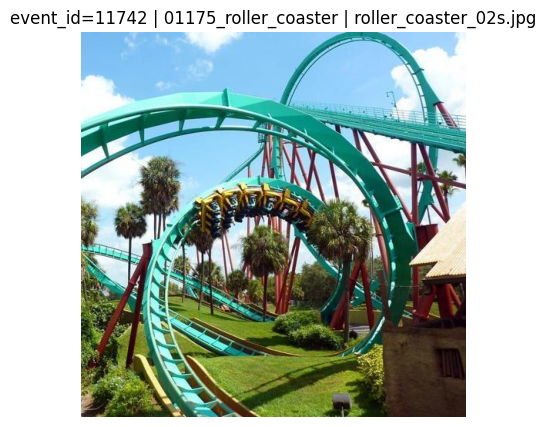

In [13]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

metadata_path = Path("../data/processed/image_metadata.npy")
metadata = np.load(metadata_path, allow_pickle=True).item()

# Keep only valid training image events (exclude 99999 and any other special markers)
valid_events = event_values[(event_values >= 1) & (event_values <= len(metadata["train_img_files"]))]

print("First 5 valid event ids:", valid_events[:5])
print()
print("Event -> image mapping:")
for event_id in valid_events[:5]:
    idx = event_id - 1
    concept = metadata["train_img_concepts"][idx]
    image_file = metadata["train_img_files"][idx]
    print(f"event_id={event_id:>5} | concept={concept} | image_file={image_file}")

# Show the first corresponding image
first_event_id = int(valid_events[0])
first_idx = first_event_id - 1
first_concept = metadata["train_img_concepts"][first_idx]
first_image_file = metadata["train_img_files"][first_idx]

image_path = Path("../data/raw/images/training_images") / first_concept / first_image_file
image = Image.open(image_path)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title(f"event_id={first_event_id} | {first_concept} | {first_image_file}")
plt.show()